In [5]:
# Imports.
import numpy as np;
import xarray as xr;
import matplotlib.pyplot as plt;
import h5_reader_xr as reader;
import f2D_utilities as utils;
from matplotlib.animation import FuncAnimation;

# Styling.
plt.style.use("ggplot");

In [6]:
# Test inputs - delete when done!
directory_path = "/zhisongqu_data/seth/GYSELA/raw/fresh_batch_9.0/DN_QSCAN_RECTEST_1.5";
delta_t = reader.fetch_delta_t(directory_path);
data_arrays = reader.fetch_f2D_data(directory_path);

Found 2001 files in the directory. Beginning compilation...
Compiled data from 1000 files...
Compiled data from 2000 files...
Finished compiling data from all files in the directory.


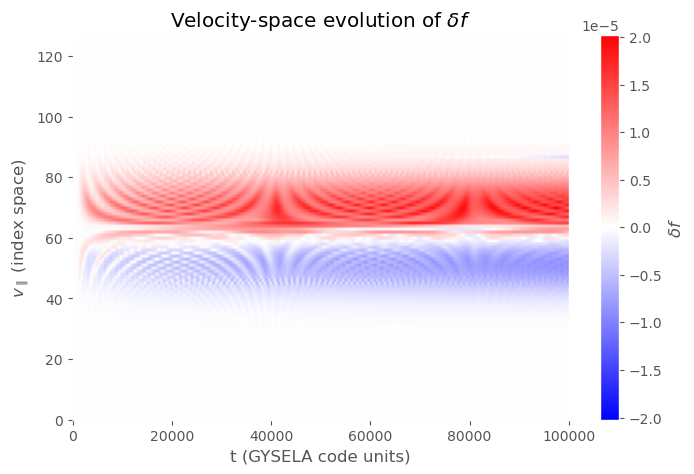

In [8]:
def plot_velocity_evolution(f2D_list, dt_diag, delta_t):

	vpar, delta_f_vpar_time = utils.compute_delta_f_vpar(f2D_list);
	time_range = np.arange(len(delta_f_vpar_time)) * dt_diag;
	
	plt.figure(figsize=(8, 5));
	plt.imshow(
		delta_f_vpar_time.T,
		aspect = "auto",
		origin = "lower",
		extent = [time_range[0], time_range[-1], vpar[0], vpar[-1]],
		cmap = "bwr",
		vmin = -np.max(np.abs(delta_f_vpar_time)),
		vmax =  np.max(np.abs(delta_f_vpar_time)),
	);
	plt.title(r"Velocity-space evolution of $\delta f$");
	plt.xlabel("t (GYSELA code units)");
	plt.ylabel(r"$v_\parallel$ (index space)");
	plt.colorbar(label = r"$\delta f$");
	plt.grid(False);
	plt.show();

plot_velocity_evolution(data_arrays, dt_diag = 50, delta_t = delta_t);